In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import json

In [2]:
import rbo

In [3]:
# A little demo of RBO
for p in [0.9, 0.99]:
    print(f"RBO p={p}")
    ref = np.arange(7) + 1
    print(ref, ref, rbo.rbo(ref, ref, p=p).ext)
    for i in range(6):
        other = ref.copy()
        other[i], other[i+1] = other[i + 1], other[i]
        print(other, ref, rbo.rbo(other, ref, p=p).ext)
    print()

RBO p=0.9
[1 2 3 4 5 6 7] [1 2 3 4 5 6 7] 1.0
[2 1 3 4 5 6 7] [1 2 3 4 5 6 7] 0.8999999999999999
[1 3 2 4 5 6 7] [1 2 3 4 5 6 7] 0.955
[1 2 4 3 5 6 7] [1 2 3 4 5 6 7] 0.973
[1 2 3 5 4 6 7] [1 2 3 4 5 6 7] 0.9817749999999998
[1 2 3 4 6 5 7] [1 2 3 4 5 6 7] 0.9868779999999999
[1 2 3 4 5 7 6] [1 2 3 4 5 6 7] 0.9901584999999999

RBO p=0.99
[1 2 3 4 5 6 7] [1 2 3 4 5 6 7] 1.0
[2 1 3 4 5 6 7] [1 2 3 4 5 6 7] 0.99
[1 3 2 4 5 6 7] [1 2 3 4 5 6 7] 0.99505
[1 2 4 3 5 6 7] [1 2 3 4 5 6 7] 0.996733
[1 2 3 5 4 6 7] [1 2 3 4 5 6 7] 0.9975742525
[1 2 3 4 6 5 7] [1 2 3 4 5 6 7] 0.9980788079799999
[1 2 3 4 5 7 6] [1 2 3 4 5 6 7] 0.9984150165835



In [4]:
from pathlib import Path
import rbo # https://github.com/dlukes/rbo

def make_data_frame(folder_path="data/rank_correlations", sub_datasets=None, sub_generators=None, sub_metrics=None, sub_judges=None, rbo_p=0.9):

    # Load json
    folder = Path(folder_path)
    data = {}

    judges_seen = set()
    for json_file in folder.glob("*.json"):
        
        with json_file.open("r", encoding="utf-8") as f:
            dataset, model = "", ""

            if 'llama-3b' in json_file.name:
                model = 'llama-3b'
            elif 'llama-8b' in json_file.name:
                model = 'llama-8b'
            elif 'qwen-0.5b' in json_file.name:
                model = 'qwen-0.5b'
            elif 'qwen-7b' in json_file.name:
                model = 'qwen-7b'
            else:
                raise ValueError(f"Unkonwn model: {json_file}")
                
            if 'ambig_qa_single' in json_file.name:
                dataset = 'ambig_qa_single'
            elif 'ambig_qa_multiple' in json_file.name:
                dataset = 'ambig_qa_multiple'
            elif 'trivia_qa' in json_file.name:
                dataset = 'trivia_qa'
            else:
                raise ValueError(f"Unkonwn dataset: {json_file}")

            data[json_file.name] = {'dataset': dataset, 'model': model, 'data': json.load(f)}
    
    
    headers = ['Dataset', 'Generator', 'Judge type', 'Judge', 'F1', 'Rank correlation', 'Metric']
    table = []
    
    for k, v in data.items():
        # print(v['dataset'], v['model'])
        # print()
        for rec in v['data']['data']:        
            # print("\t", rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'])
            judges_seen.add(rec['judge'])

            rsim = rbo.rbo(rec['judge_rankings'], np.arange(len(rec['judge_rankings'])) + 1, p=rbo_p).ext

            jf = rec['judge'].split("_")[0]
            if jf == 'llm':
                jf = rec['judge'].split("_")[0] + "-" + rec['judge'].split("_")[-1]

            
            if sub_judges:
                if rec['judge'] in sub_judges:
                    if isinstance(sub_judges, dict):
                        jn = sub_judges[rec['judge']]
                    else:
                        jn = rec['judge']
                else:
                    continue
            else:
                jn = rec['judge']
            
            # table.append([v['dataset'], v['model'],  jf, rec['judge'], rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'], rec['rank_correlation_spearman']['spearmanr'], rsim])
            table.append([v['dataset'], v['model'],  jf, jn, rec['f1_score'], rec['rank_correlation_kendall']['kendalltau'], 'Kendall'])
            table.append([v['dataset'], v['model'],  jf, jn, rec['f1_score'], rec['rank_correlation_spearman']['spearmanr'], 'Spearman'])
            table.append([v['dataset'], v['model'],  jf, jn, rec['f1_score'], rsim, 'RBO'])

    df = pd.DataFrame(
        table,
        columns=headers,
    )
    if sub_datasets:
        df = df[df['Dataset'].isin(sub_datasets)]
    if sub_generators:
        df = df[df['Generator'].isin(sub_generators)]
    if sub_metrics:
        df = df[df['Metric'].isin(sub_metrics)]

    return df

In [69]:
df = make_data_frame(
    sub_datasets={'trivia_qa'},
    sub_generators={'qwen-7b', 'llama-8b'},
    sub_metrics={'Kendall', 'RBO'},
)
df

,Dataset,Generator,Judge type,Judge,F1,Rank correlation,Metric
255,trivia_qa,qwen-7b,llm-os,llm_as_judge_correctness_os,0.896552,0.904762,Kendall
257,trivia_qa,qwen-7b,llm-os,llm_as_judge_correctness_os,0.896552,0.990158,RBO
258,trivia_qa,qwen-7b,llm-api,llm_as_judge_correctness_api,0.957265,0.904762,Kendall
260,trivia_qa,qwen-7b,llm-api,llm_as_judge_correctness_api,0.957265,0.990158,RBO
261,trivia_qa,qwen-7b,token,token_f1_0.1,0.615385,0.333333,Kendall
...,...,...,...,...,...,...,...
542,trivia_qa,llama-8b,embedding,embedding_similarity_0.9,0.106667,0.813586,RBO
543,trivia_qa,llama-8b,bert,bert_score_0.8,0.873418,0.523810,Kendall
545,trivia_qa,llama-8b,bert,bert_score_0.8,0.873418,0.858812,RBO
546,trivia_qa,llama-8b,bert,bert_score_0.9,0.106667,0.333333,Kendall


In [70]:
sorted(df['Dataset'].unique())

['trivia_qa']

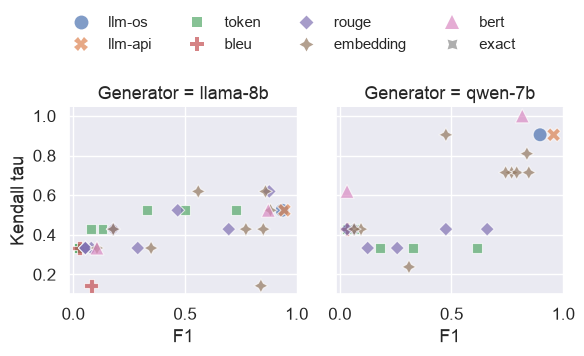

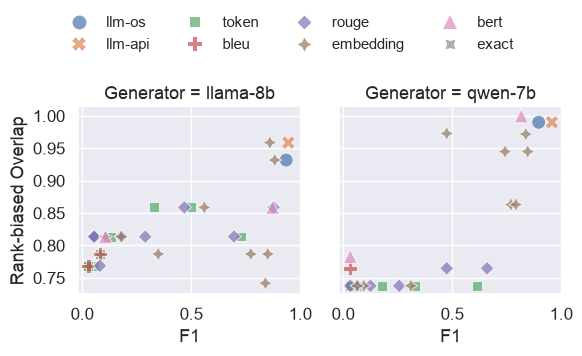

In [74]:
sns.set_theme(style="darkgrid")

for metric in ['Kendall', 'RBO']:

    with sns.plotting_context("notebook", font_scale=1.1):
        
        g= sns.relplot(
            df[df['Metric']==metric],
            x='F1',
            y='Rank correlation',
            style='Judge type',
            hue='Judge type',
            # hue='UQ',
            # style='annotation',
            # row='Metric',
            
            s=100,
            alpha=0.7, 
            # row_order=['llama-8b', 'qwen-7b'],
            # row='Generator',
            # height=2.5,
            # aspect=1.5,
            col_order=['llama-8b', 'qwen-7b'],
            col='Generator',
            height=3,
            # # aspect=1.5,
        )
        g._legend.set_title("Judge")
        if metric == 'Kendall':
            g.set_ylabels("Kendall tau")
        else:
            g.set_ylabels("Rank-biased Overlap")
    
    # sns.move_legend(g, "lower center")
    sns.move_legend(
        g, "lower center",
        bbox_to_anchor=(.43, 1), ncol=4, title=None, frameon=False, fontsize=11, title_fontsize=10
    )
    g.savefig(f"otherstuff/F1-{metric}-triviaqa-colwise-legend-above.pdf")

In [76]:
df_all = make_data_frame(
    # sub_datasets={'trivia_qa'},
    # sub_generators={'qwen-7b', 'llama-8b'},
    sub_metrics={'Kendall', 'RBO'},
)
df_all['Generator'].unique()

<StringArray>
['qwen-7b', 'llama-8b', 'llama-3b', 'qwen-0.5b']
Length: 4, dtype: str

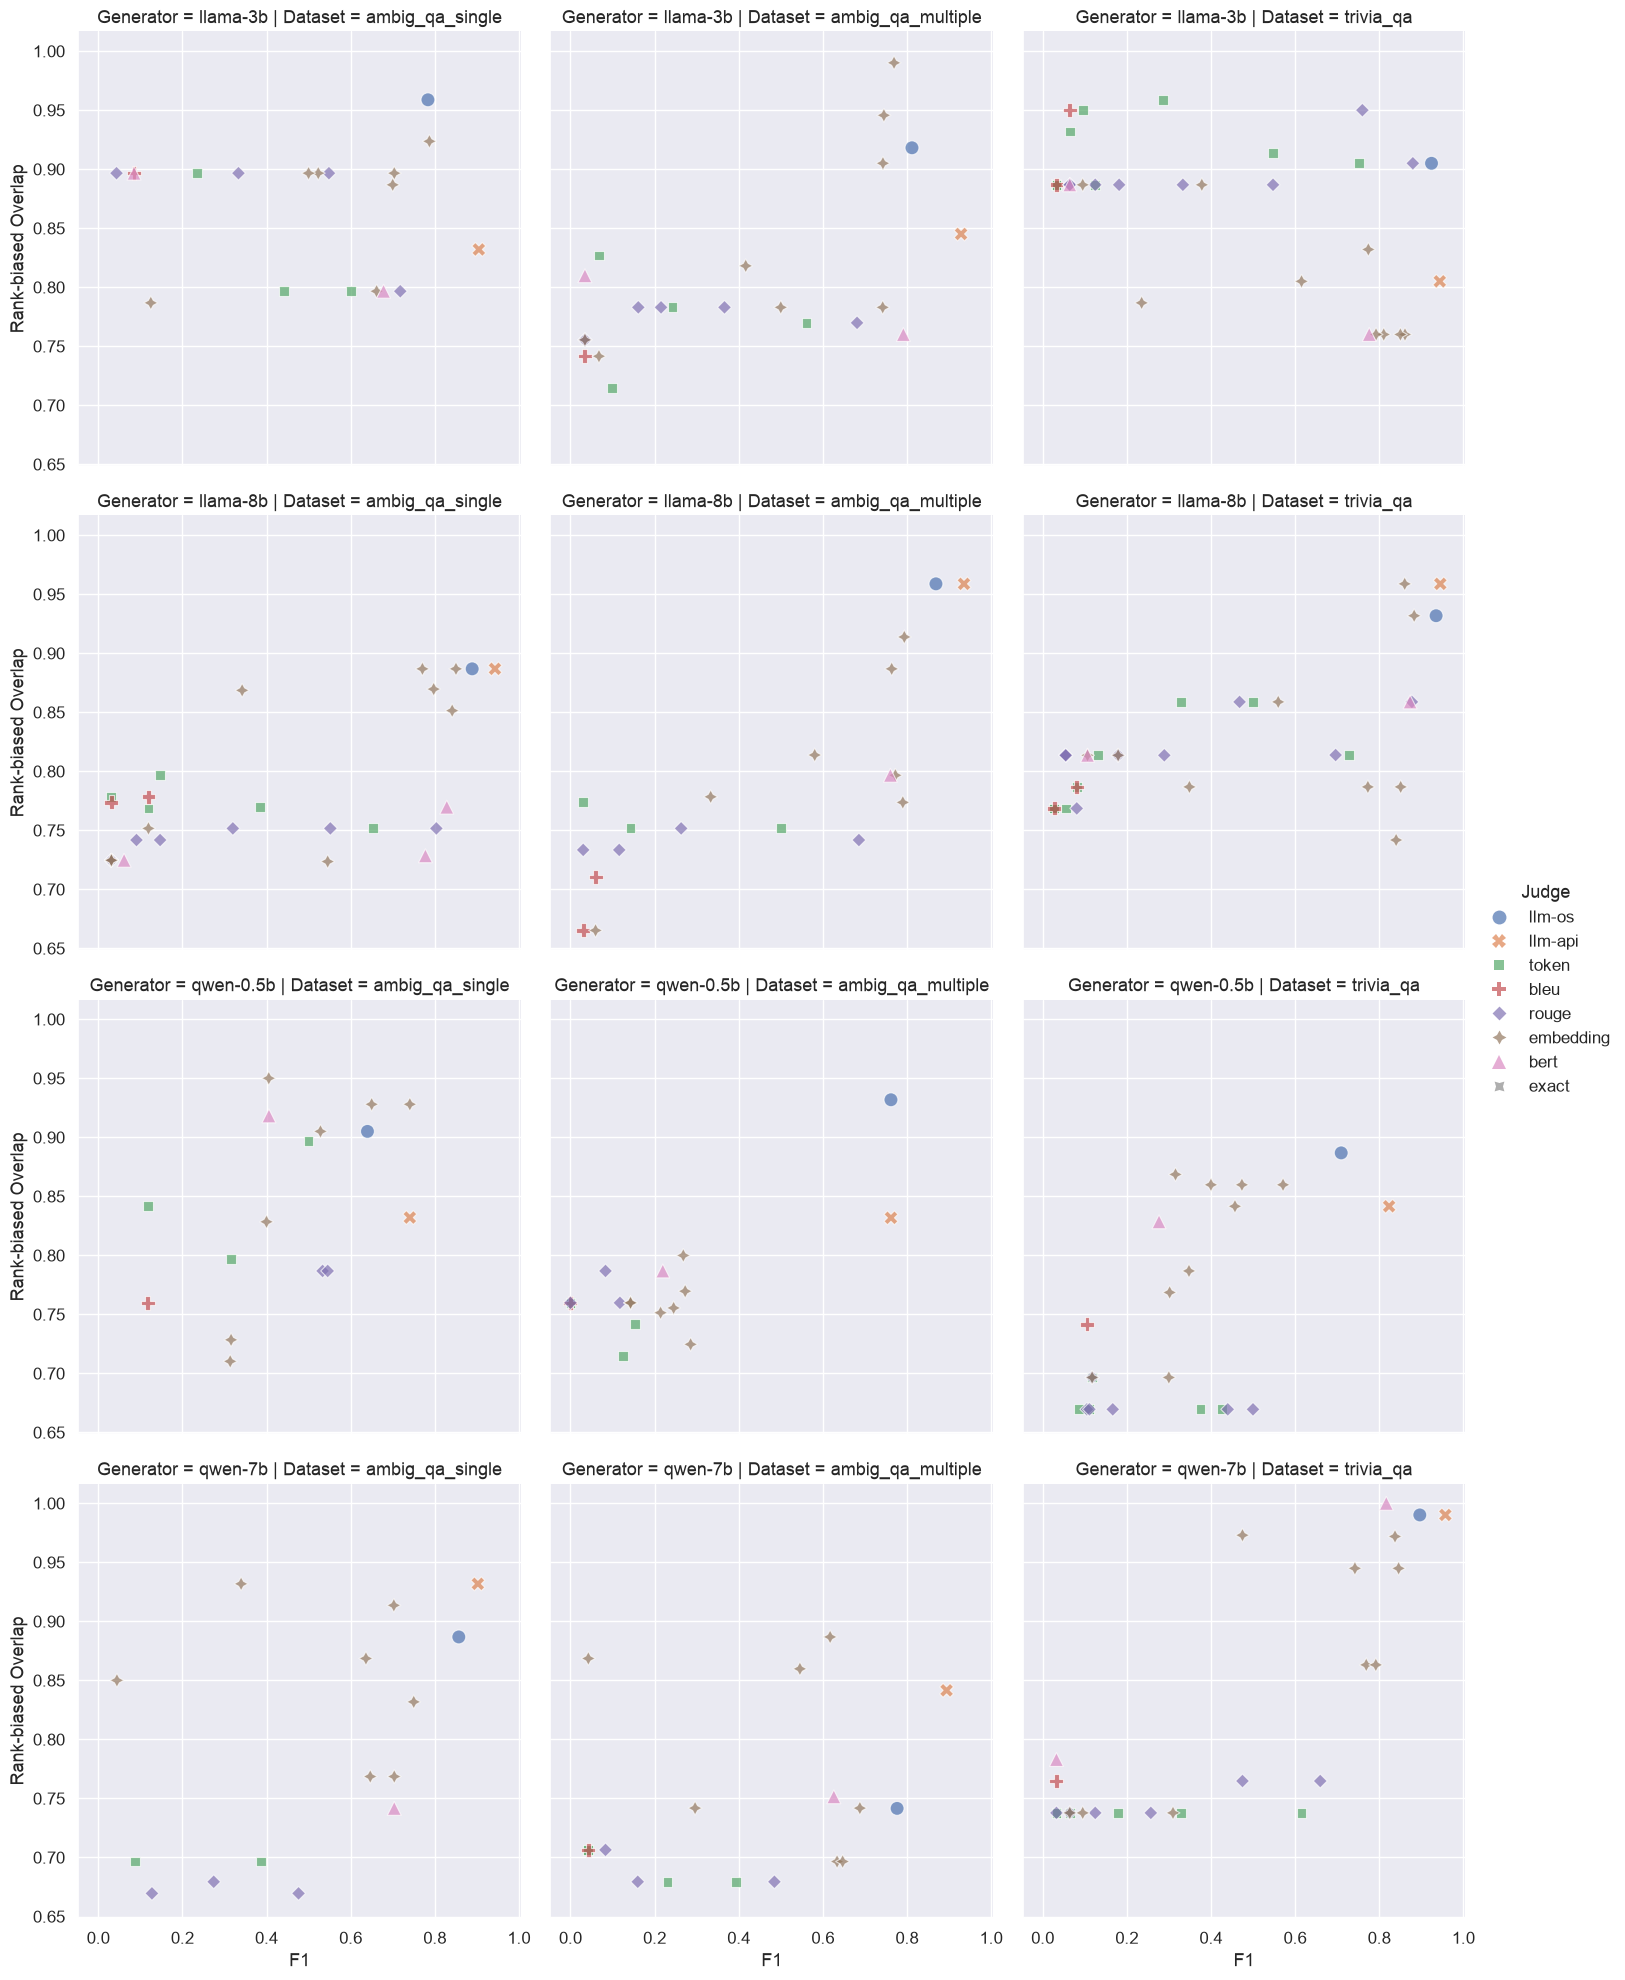

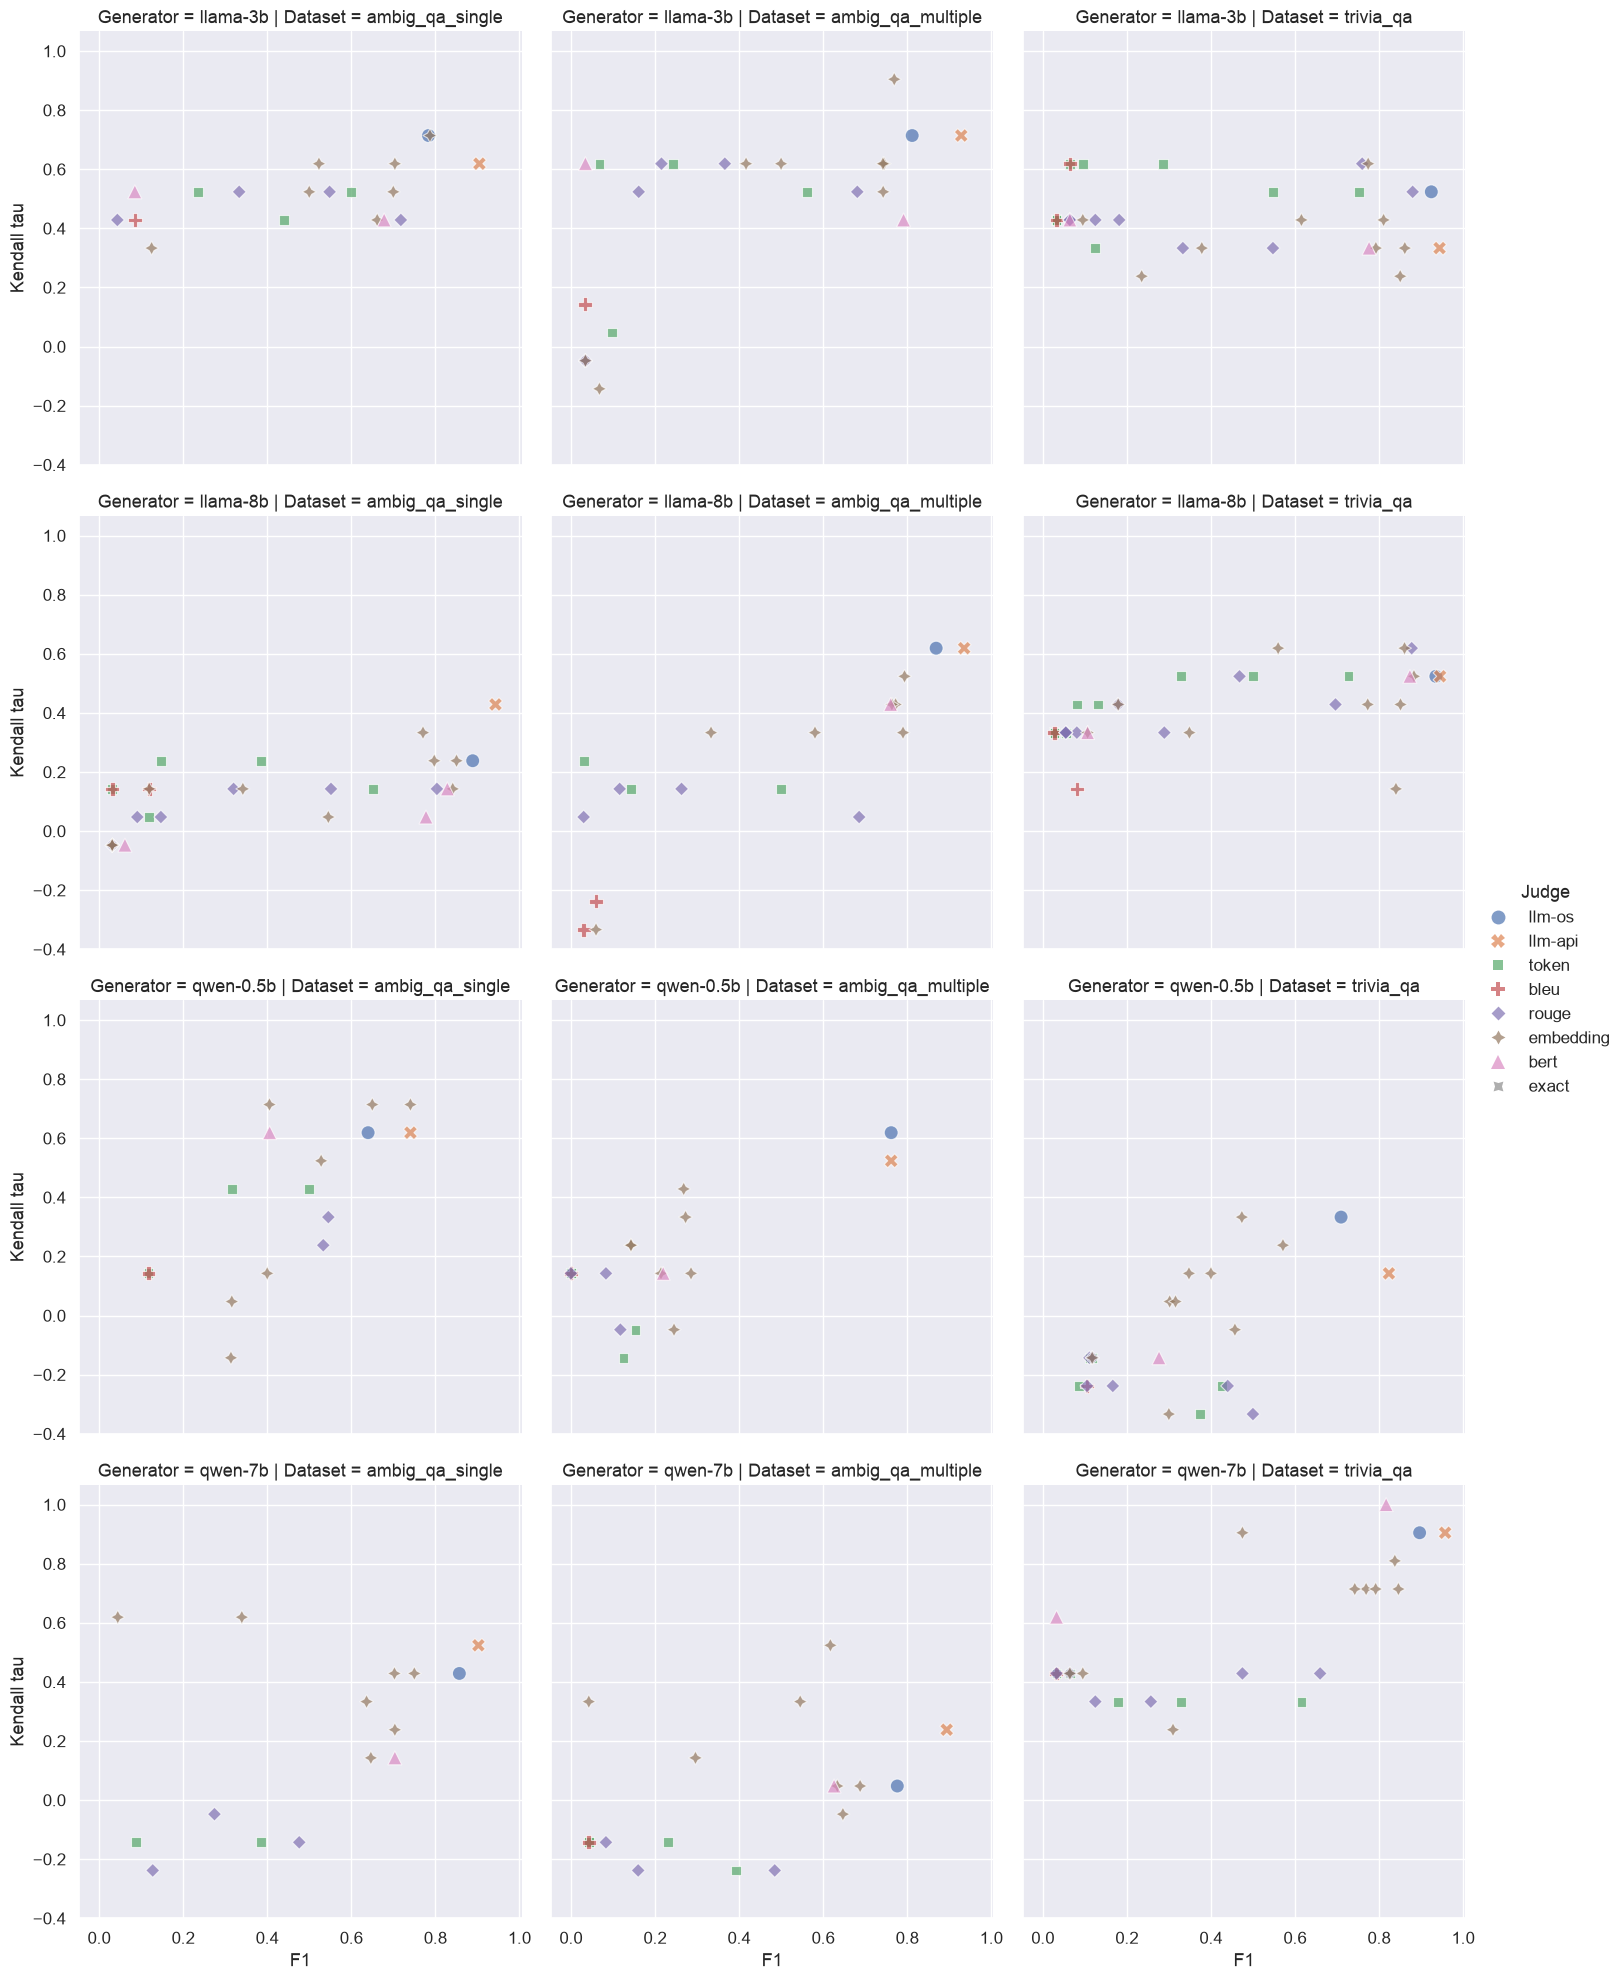

In [77]:


sns.set_theme(style="darkgrid")

for metric in ['RBO', 'Kendall']:

    with sns.plotting_context("notebook", font_scale=1.1):
        
        g= sns.relplot(
            df_all[df_all['Metric']==metric],
            x='F1',
            y='Rank correlation',
            style='Judge type',
            hue='Judge type',
            s=100,
            alpha=0.7, 
            col='Dataset',
            col_order=['ambig_qa_single', 'ambig_qa_multiple', 'trivia_qa'],
            row='Generator',
            row_order=['llama-3b', 'llama-8b', 'qwen-0.5b', 'qwen-7b'],
        )
        g._legend.set_title("Judge")
        if metric == 'Kendall':
            g.set_ylabels("Kendall tau")
        else:
            g.set_ylabels("Rank-biased Overlap")
    g.savefig(f"inlg2026/scatter-F1-{metric}-all.pdf")